In [1]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from pathlib import Path
import itk


In [2]:
PET_PATH = Path('data/02324177_s2_e_1_BRAIN_DINAMIC_COLINA_AC_FORISI260916')
MR_PATH  = Path('data/15252129_s1_AX_3D_T1__C_FSPGR_FORISI260916')

pet_ds = pydicom.dcmread(PET_PATH)
mr_ds  = pydicom.dcmread(MR_PATH)

# MR Inspection

In [3]:
print(f'Pixel Array Shape: {mr_ds.pixel_array.shape}')
print(f'Pixel Spacing: {mr_ds["PixelSpacing"].value}')
print(f'Slice Spacing: {mr_ds["SpacingBetweenSlices"].value}')

Pixel Array Shape: (156, 256, 256)
Pixel Spacing: [1.0, 1.0]
Slice Spacing: 1.0


## Verify Slice Ordering

In [7]:
print(f'PerFrameFunctionalGroupsSequence: {mr_ds["PerFrameFunctionalGroupsSequence"].value}')


KeyError: (5200,9230)

In [ ]:
mr_itk = itk.imread(str(MR_PATH))

print(f"Largest Possible Region Shape: {mr_itk.GetLargestPossibleRegion().GetSize()}")
print(f"Spacing: {mr_itk.GetSpacing()}")
print(f"Origin: {mr_itk.GetOrigin()}")
print(f"Direction: {mr_itk.GetDirection()}")


Largest Possible Region Shape: itkSize3 ([256, 256, 156])
Spacing: itkVectorD3 ([1, 1, 1])
Origin: itkPointD3 ([-127.054, -169.357, -75.0121])
Direction: itkMatrixD33 ([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])


AttributeError: 'itkImageSS3' object has no attribute 'rows'

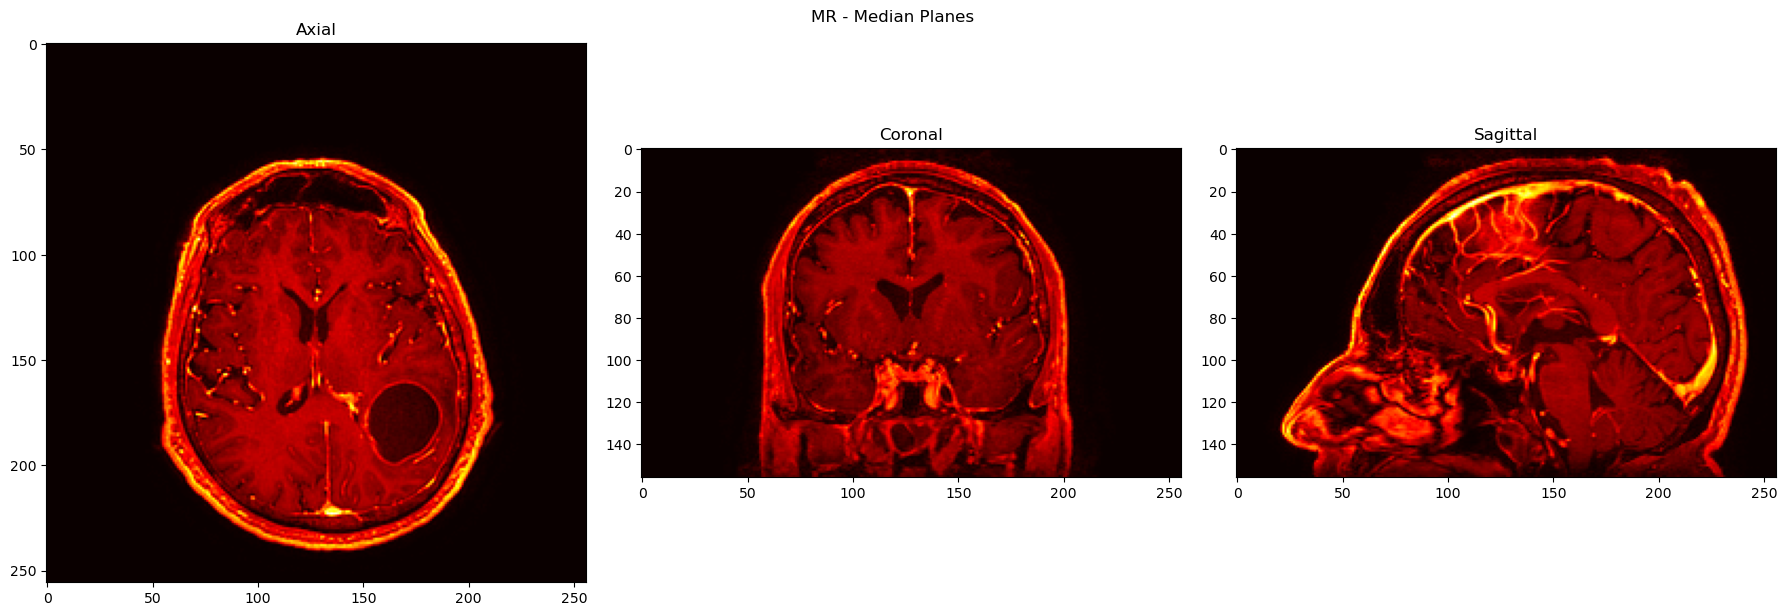

In [ ]:
spacing_between_slices = float(mr_itk.GetSpacing()[0])  
rows = mr_itk.GetLargestPossibleRegion().GetSize()[0]   
cols = mr_itk.GetLargestPossibleRegion().GetSize()[1]    

arr = itk.array_from_image(mr_itk)   # shape (z, y, x) = (156, 256, 256)
nz, ny, nx = arr.shape

# ONLY FOR VISUALIZATION DO NOT USE IN FOLLOWING TASKS
axial    = arr[nz//2]
coronal  = arr[::-1, ny//2, :]
sagittal = arr[::-1, :, nx//2]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'MR - Median Planes ')

axes[0].imshow(axial,    cmap='hot', aspect='equal')
axes[0].set_title('Axial')

axes[1].imshow(coronal,  cmap='hot', aspect='equal')
axes[1].set_title('Coronal')

axes[2].imshow(sagittal,  cmap='hot', aspect='equal')
axes[2].set_title('Sagittal')

plt.tight_layout()
plt.show()